23070521054 - GAURI GULHANE

Epoch 1/5 complete
Epoch 2/5 complete
Epoch 3/5 complete
Epoch 4/5 complete
Epoch 5/5 complete


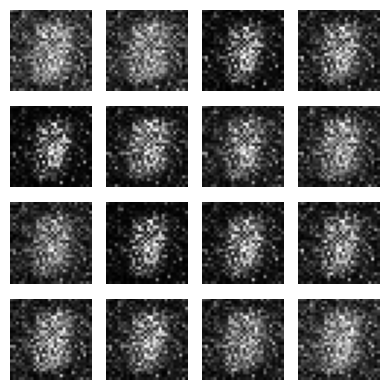

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = (x_train.astype("float32") - 127.5) / 127.5
x_train = x_train.reshape(-1, 784)
dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(60000).batch(128)

G = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(100,)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(784, activation="tanh")
])

D = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

loss_fn = tf.keras.losses.BinaryCrossentropy()
g_opt = tf.keras.optimizers.Adam(0.0002)
d_opt = tf.keras.optimizers.Adam(0.0002)

@tf.function
def train_step(real):
    batch_size = tf.shape(real)[0]
    noise = tf.random.normal((batch_size, 100))
    with tf.GradientTape() as gt, tf.GradientTape() as dt:
        fake = G(noise, training=True)
        d_real_pred = D(real, training=True)
        d_fake_pred = D(fake, training=True)

        d_loss = loss_fn(tf.ones_like(d_real_pred), d_real_pred) + loss_fn(tf.zeros_like(d_fake_pred), d_fake_pred)
        g_loss = loss_fn(tf.ones_like(d_fake_pred), d_fake_pred)

    d_grads = dt.gradient(d_loss, D.trainable_variables)
    g_grads = gt.gradient(g_loss, G.trainable_variables)

    d_opt.apply_gradients(zip(d_grads, D.trainable_variables))
    g_opt.apply_gradients(zip(g_grads, G.trainable_variables))
    return d_loss, g_loss

for epoch in range(5):
    for real in dataset:
        train_step(real)
    print(f"Epoch {epoch + 1}/5 complete")

images = G(tf.random.normal((16, 100)), training=False).numpy().reshape(16, 28, 28)
plt.figure(figsize=(4, 4))
for i, image in enumerate(images):
    plt.subplot(4, 4, i + 1)
    plt.imshow(image, cmap="gray")
    plt.axis("off")
plt.tight_layout()
plt.show()